In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# =========================
# STEP 1: IMPORTS
# =========================

import os
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

In [9]:
# =========================
# STEP 2: OPTIMIZED DATA LOADING FUNCTIONS
# (Fixed ROI schema, no repeated schema search)
# =========================

# Paste the full most common ROI schema tuple here once you have it.
# Example:
# TARGET_SCHEMA = ('ROI_1', 'ROI_2', 'ROI_3', ...)
TARGET_SCHEMA = None

# Fallback: use ROI count if full schema is not pasted yet.
TARGET_ROI_COUNT = 19

# Set this to True when you paste the exact schema tuple above.
USE_FULL_SCHEMA = False


def load_dataset(root_dir):
    """
    Load raw timeseries without normalization.
    Uses a fixed ROI schema to avoid repeated full-dataset schema scans.
    Normalization will be applied after subject-level split.
    """
    dataset = []
    print("Scanning and loading dataset (optimized fixed schema mode)...")

    for root, dirs, files in os.walk(root_dir):
        for f in files:
            if not f.endswith(".npz"):
                continue

            file_path = os.path.join(root, f)

            try:
                relative_path = os.path.relpath(file_path, root_dir)
                subject_name = relative_path.split(os.sep)[0]

                with np.load(file_path, allow_pickle=True) as data:
                    if "roi_labels" not in data or "timeseries" not in data:
                        continue

                    roi_labels = tuple(map(str, data["roi_labels"].tolist()))

                    # Full schema match (recommended for research validity)
                    if USE_FULL_SCHEMA:
                        if TARGET_SCHEMA is None:
                            raise ValueError("TARGET_SCHEMA is None. Paste the full ROI schema tuple first.")
                        if roi_labels != TARGET_SCHEMA:
                            continue

                    # ROI-count fallback (faster, but less strict)
                    else:
                        if len(roi_labels) != TARGET_ROI_COUNT:
                            continue

                    ts = data["timeseries"].astype(np.float32)

                    if ts.ndim != 2:
                        continue

                    # Ensure shape is (T, ROI)
                    if ts.shape[0] < ts.shape[1]:
                        ts = ts.T

                    expected_roi_count = len(TARGET_SCHEMA) if (USE_FULL_SCHEMA and TARGET_SCHEMA is not None) else TARGET_ROI_COUNT
                    if ts.shape[1] != expected_roi_count:
                        continue

                    dataset.append({
                        "timeseries": ts,
                        "subject": subject_name,
                        "roi_labels": roi_labels
                    })

            except Exception:
                continue

    subjects_found = sorted(set(d["subject"] for d in dataset))
    print(f"Loaded: {len(dataset)} runs from {len(subjects_found)} subjects")
    print(f"Subjects: {subjects_found}")

    return dataset

In [15]:
# =========================
# STEP 3: DATASET INITIALIZATION (FAST COLAB COPY + FIXED SCHEMA LOAD)
# =========================

import os
import time

# Source path on Google Drive
drive_root_dir = "/content/drive/MyDrive/PROJE_FMRI/Copy of pooled_stratified_share/pooled_stratified_share"

# Local path in Colab runtime
local_root_dir = "/content/pooled_stratified_share"

# Always refresh local copy to avoid partial / stale copies
print("Removing old local dataset (if exists)...")
!rm -rf /content/pooled_stratified_share

print("Copying dataset from Drive to local runtime...")
start_copy = time.time()
!cp -r "{drive_root_dir}" /content/
end_copy = time.time()

print(f"Copy completed in {end_copy - start_copy:.2f} seconds")

# Use local dataset path
root_dir = local_root_dir

if not os.path.exists(root_dir):
    raise ValueError(f"ERROR: Dataset folder not found: {root_dir}")

print(f"Using dataset path: {root_dir}")

# Load dataset directly using fixed schema settings from STEP 2
start_total = time.time()

print("Loading dataset with fixed schema settings...")
start_load = time.time()
dataset = load_dataset(root_dir)
end_load = time.time()

print(f"Successfully loaded runs: {len(dataset)}")
print(f"Loading time: {end_load - start_load:.2f} seconds")

end_total = time.time()
print(f"Total STEP 3 time: {end_total - start_total:.2f} seconds")

Removing old local dataset (if exists)...
Copying dataset from Drive to local runtime...
Copy completed in 420.11 seconds
Using dataset path: /content/pooled_stratified_share
Loading dataset with fixed schema settings...
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2144 runs from 6 subjects
Subjects: ['subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Successfully loaded runs: 2144
Loading time: 1.70 seconds
Total STEP 3 time: 1.70 seconds


In [16]:
# =========================
# STEP 4: RUN-LEVEL NORMALIZATION + WINDOWING UTILITIES
# =========================

def normalize_items(items, eps=1e-8):
    """
    Apply run-level z-score normalization.

    Each run is normalized independently:
        - mean/std are computed per ROI within that run only
        - this avoids cross-subject distribution distortion
        - this is safer for BOLD forecasting under LOSO-CV
    """
    normalized = []

    for item in items:
        ts = item["timeseries"]

        mean = ts.mean(axis=0, keepdims=True).astype(np.float32)
        std = ts.std(axis=0, keepdims=True).astype(np.float32)
        std = np.maximum(std, eps)

        ts_norm = ((ts - mean) / std).astype(np.float32)

        normalized.append({
            **item,
            "timeseries": ts_norm,
            "run_mean": mean,
            "run_std": std
        })

    return normalized


def build_multi_step_windows(data_list, M, H, stride=1):
    """
    Convert time series into supervised learning windows.

    Input:
        X -> (M, ROI)

    Target:
        Y -> (H, ROI)
    """
    X, Y = [], []

    for item in data_list:
        ts = item["timeseries"]

        if len(ts) < (M + H):
            continue

        for t in range(0, len(ts) - M - H + 1, stride):
            X.append(ts[t:t + M])
            Y.append(ts[t + M:t + M + H])

    if len(X) == 0:
        return np.empty((0, M, 0), dtype=np.float32), np.empty((0, H, 0), dtype=np.float32)

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


def split_by_subject(dataset, test_ratio=0.2, test_subjects=None, random_state=42):
    """
    Flexible subject split.

    Modes:
    1. LOSO mode:
        - provide test_subjects explicitly

    2. Random split mode:
        - use test_ratio
    """
    subjects = sorted(set(item["subject"] for item in dataset))

    if test_subjects is not None:
        train_subjects = [s for s in subjects if s not in test_subjects]
        test_subjects = list(test_subjects)
    else:
        rng = np.random.default_rng(random_state)
        rng.shuffle(subjects)

        split_idx = int(len(subjects) * (1 - test_ratio))
        train_subjects = subjects[:split_idx]
        test_subjects = subjects[split_idx:]

    train_items = [item for item in dataset if item["subject"] in train_subjects]
    test_items = [item for item in dataset if item["subject"] in test_subjects]

    print(f"Train subjects: {train_subjects}")
    print(f"Test subjects : {test_subjects}")
    print(f"Train runs: {len(train_items)}")
    print(f"Test runs : {len(test_items)}")

    return train_items, test_items

In [17]:
# =========================
# STEP 5: PYTORCH DATASET & DATALOADERS
# =========================

class FMRIWindowDataset(Dataset):
    """PyTorch dataset for fMRI windowed sequences."""

    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


batch_size = 512

In [18]:
#=========================
# STEP 6: ADVANCED LSTM MODEL
# (Architecture unchanged — well structured)
# =========================

class AdvancedLSTM(nn.Module):
    """
    Multi-layer LSTM for multi-step fMRI BOLD forecasting.
    Takes a sequence of M past ROI vectors and predicts H future steps.
    """

    def __init__(self, input_size, hidden_size=512, num_layers=3,
                 output_horizon=5, dropout=0.5):
        super().__init__()

        self.output_horizon = output_horizon
        self.input_size = input_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_horizon * input_size)

    def forward(self, x):
        # x: (batch, M, roi)
        _, (h_n, _) = self.lstm(x)
        last_h = h_n[-1]                          # last layer hidden state
        out = self.fc(last_h)                      # (batch, H * roi)
        return out.view(-1, self.output_horizon, self.input_size)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")



Device: cuda


In [19]:
# =========================
# STEP 7: TRAINING LOOP (ADAMW + SCHEDULER + EARLY STOPPING)
# (Updated: DeltaAwareLoss replaces MSELoss — better spike detection)
# =========================

class DeltaAwareLoss(nn.Module):
    """
    Combined loss: HuberLoss + delta (change) penalty.

    HuberLoss  — robust to outliers, less conservative than MSE on spikes.
    Delta term — penalizes wrong direction predictions, forces model
                 to learn sudden changes, not just mean-level signal.

    alpha controls how much the direction penalty contributes.
    delta controls the Huber threshold (below=MSE, above=MAE behavior).
    """
    def __init__(self, alpha=0.3, delta=0.5):
        super().__init__()
        self.alpha = alpha
        self.base  = nn.HuberLoss(delta=delta)

    def forward(self, pred, target):
        base_loss    = self.base(pred, target)

        # Change between consecutive forecast steps
        pred_delta   = pred[:, 1:, :]   - pred[:, :-1, :]
        target_delta = target[:, 1:, :] - target[:, :-1, :]
        delta_loss   = self.base(pred_delta, target_delta)

        return base_loss + self.alpha * delta_loss


def train_model(model, train_loader, val_loader=None,
                num_epochs=30, device="cpu", patience=5):

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=5e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2)

    criterion = DeltaAwareLoss(alpha=0.3, delta=0.5)

    best_val_loss   = float('inf')
    patience_counter = 0
    best_state      = None

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        total_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}",
                    leave=False)
        for X_batch, Y_batch in loop:
            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        scheduler.step(avg_loss)

        # --- Validation + Early Stopping ---
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    val_loss += criterion(
                        model(xb.to(device)), yb.to(device)).item()
            val_loss /= len(val_loader)

            print(f"  Epoch {epoch+1:2d} | train: {avg_loss:.6f} "
                  f"| val: {val_loss:.6f}")

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                best_state       = {k: v.clone()
                                    for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                print(f"  No improvement ({patience_counter}/{patience})")
                if patience_counter >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break
        else:
            print(f"  Epoch {epoch+1:2d} | train loss: {avg_loss:.6f}")

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  Best val loss: {best_val_loss:.6f} — weights restored")

    return model

In [21]:
# =========================
# STEP 8: EVALUATION & METRICS
# (FIXED: compute_eta now uses information-theoretic formula from Slide 11)
# =========================

def get_predictions(model, loader, device):
    """Runs inference and returns concatenated predictions and targets."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb.to(device))
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)


def compute_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def compute_naive_rmse(X_test, Y_test):
    """Naive baseline: repeat last observed frame for all H future steps."""
    naive_preds = np.repeat(X_test[:, -1:, :], Y_test.shape[1], axis=1)
    return compute_rmse(Y_test, naive_preds)


def compute_eta(y_true, y_pred):
    """
    Information-theoretic eta: η = I(Y; Ŷ) / H(Y)  [Slide 11]

    Computed per ROI under Gaussian assumption, then averaged:
        I(Y; Ŷ) = -0.5 * log(1 - r²)       [nats]  — mutual information
        H(Y)    =  0.5 * log(2πe * σ²_Y)   [nats]  — signal entropy
        η       = I / H                              — fraction explained

    NOTE: This is NOT R² (explained variance = 1 - MSE/Var).
    R² can be negative; η is bounded and information-theoretically grounded.
    """
    # Flatten H and roi dims if 3D: (N, H, roi) → (N*H, roi)
    if y_true.ndim == 3:
        y_true = y_true.reshape(-1, y_true.shape[-1])
        y_pred = y_pred.reshape(-1, y_pred.shape[-1])

    n_roi = y_true.shape[1]
    etas = []

    for roi in range(n_roi):
        yt = y_true[:, roi]
        yp = y_pred[:, roi]

        if yt.std() < 1e-8 or yp.std() < 1e-8:
            continue

        r = np.corrcoef(yt, yp)[0, 1]
        r = np.clip(r, -1 + 1e-7, 1 - 1e-7)

        mi = -0.5 * np.log(1 - r ** 2)                        # I(Y; Ŷ)
        hy =  0.5 * np.log(2 * np.pi * np.e * (yt.var() + 1e-12))  # H(Y)
        etas.append(mi / (hy + 1e-12))

    return float(np.nanmean(etas))


def horizon_rmse(y_true, y_pred):
    """Compute and print RMSE separately for each forecast step."""
    horizon_scores = []
    print("\nHorizon-wise RMSE:")
    for h in range(y_true.shape[1]):
        r = compute_rmse(y_true[:, h, :], y_pred[:, h, :])
        horizon_scores.append(r)
        print(f"  Step {h+1} RMSE: {r:.6f}")
    return horizon_scores

In [22]:
# =========================
# STEP 9: LOSO-CV WITH PROGRESS BARS
# (Updated: early stopping + validation loader + best eta model tracking)
# =========================

from tqdm.auto import tqdm
import pandas as pd

def run_loso_cv(dataset_raw, M=20, H=3, stride=1,
                num_epochs=20, batch_size=512, device=device):
    """
    Leave-One-Subject-Out Cross Validation (LOSO-CV).

    Each run is normalized independently (run-level z-score).
    A fresh model is trained from scratch for every fold.
    10% of train windows used as validation set for early stopping.
    Tracks best eta model across all folds and returns it separately.

    Returns:
        df                — LOSO summary dataframe
        last_trained_model — model from the last fold
        last_X_test        — test windows from the last fold
        last_Y_test        — test targets from the last fold
        best_model         — model with highest eta across all folds
        best_X_test        — test windows of the best eta fold
        best_Y_test        — test targets of the best eta fold
    """

    subjects = sorted(set(d["subject"] for d in dataset_raw))
    n_subjects = len(subjects)

    print(f"\n{'='*60}")
    print(f"LOSO-CV | {n_subjects} subjects | M={M}, H={H}")
    print(f"{'='*60}")

    fold_results = []

    last_trained_model = None
    last_X_test        = None
    last_Y_test        = None

    best_eta_model     = None
    best_eta_score     = -float('inf')
    best_eta_subject   = None
    best_X_test        = None
    best_Y_test        = None

    for fold_i, test_subj in enumerate(tqdm(subjects, desc="LOSO Folds")):
        print(f"\nFold {fold_i+1}/{n_subjects} | Test subject: {test_subj}")

        # 1. Subject-level split
        train_items, test_items = split_by_subject(
            dataset_raw,
            test_subjects=[test_subj]
        )

        # 2. Run-level normalization (each run normalizes itself — no leakage)
        train_norm = normalize_items(train_items)
        test_norm  = normalize_items(test_items)

        # 3. Windowing
        X_tr, Y_tr = build_multi_step_windows(train_norm, M, H, stride)
        X_te, Y_te = build_multi_step_windows(test_norm,  M, H, stride)

        if len(X_tr) == 0 or len(X_te) == 0:
            print("Skipping fold (no valid windows)")
            continue

        # 4. Split train into train/val (90/10) for early stopping
        val_split    = int(len(X_tr) * 0.9)
        X_val, Y_val = X_tr[val_split:], Y_tr[val_split:]
        X_tr,  Y_tr  = X_tr[:val_split],  Y_tr[:val_split]

        n_roi = X_tr.shape[2]
        print(f"Train windows: {len(X_tr)} | Val windows: {len(X_val)} "
              f"| Test windows: {len(X_te)} | ROIs: {n_roi}")

        # 5. DataLoaders
        train_loader = DataLoader(
            FMRIWindowDataset(X_tr, Y_tr),
            batch_size=batch_size,
            shuffle=True,
            pin_memory=True
        )
        val_loader = DataLoader(
            FMRIWindowDataset(X_val, Y_val),
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True
        )
        test_loader = DataLoader(
            FMRIWindowDataset(X_te, Y_te),
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True
        )

        # 6. Fresh model per fold
        model = AdvancedLSTM(
            input_size=n_roi,
            output_horizon=H,
            hidden_size=512,
            dropout=0.5
        ).to(device)

        # 7. Train — delegates to train_model() from STEP 7
        print(f"Training (max {num_epochs} epochs, early stopping patience=5)...")
        model = train_model(
            model,
            train_loader,
            val_loader=val_loader,
            num_epochs=num_epochs,
            device=device,
            patience=5
        )

        # 8. Evaluate — delegates to get_predictions() from STEP 8
        all_preds, all_targets = get_predictions(model, test_loader, device)

        lstm_r  = compute_rmse(all_targets, all_preds)
        naive_r = compute_naive_rmse(X_te, Y_te)
        eta     = compute_eta(all_targets, all_preds)

        print(f"\nResults:")
        print(f"  LSTM RMSE  : {lstm_r:.6f}")
        print(f"  Naive RMSE : {naive_r:.6f}")
        print(f"  eta        : {eta:.4f}")
        print(f"  Beat naive : {'YES' if lstm_r < naive_r else 'NO'}")

        horizon_rmse(all_targets, all_preds)

        fold_results.append({
            "test_subject": test_subj,
            "LSTM_RMSE":  round(lstm_r,  6),
            "Naive_RMSE": round(naive_r, 6),
            "eta":        round(eta,     4),
            "beat_naive": lstm_r < naive_r,
        })

        # 9. Track last fold
        last_trained_model = model
        last_X_test        = X_te
        last_Y_test        = Y_te

        # 10. Track best eta fold
        if eta > best_eta_score:
            best_eta_score   = eta
            best_eta_subject = test_subj
            best_eta_model   = {k: v.clone()
                                for k, v in model.state_dict().items()}
            best_X_test      = X_te.copy()
            best_Y_test      = Y_te.copy()
            print(f"  New best eta model saved: {test_subj} (η={eta:.4f})")

        # 11. Memory cleanup
        del train_loader, val_loader, test_loader
        del X_tr, Y_tr, X_val, Y_val
        del train_norm, test_norm
        torch.cuda.empty_cache()

    # 12. Summary
    print(f"\n{'='*60}")
    print("LOSO-CV SUMMARY")
    print(f"{'='*60}")

    df = pd.DataFrame(fold_results)
    print(df.to_string(index=False))
    print(f"\nMean LSTM RMSE  : {df['LSTM_RMSE'].mean():.6f}")
    print(f"Mean Naive RMSE : {df['Naive_RMSE'].mean():.6f}")
    print(f"Mean eta        : {df['eta'].mean():.4f}")
    print(f"Folds beat naive: {df['beat_naive'].sum()} / {len(df)}")

    df.to_csv("loso_results.csv", index=False)
    print("\nResults saved to loso_results.csv")

    # 13. Restore best eta model
    print(f"\nBest eta fold : {best_eta_subject} (η={best_eta_score:.4f})")

    best_model = AdvancedLSTM(
        input_size=n_roi,
        output_horizon=H,
        hidden_size=512,
        dropout=0.5
    ).to(device)
    best_model.load_state_dict(best_eta_model)
    best_model.eval()

    return df, last_trained_model, last_X_test, last_Y_test, \
           best_model, best_X_test, best_Y_test

In [24]:
# =========================
# STEP 10: Train-Test
# =========================
results_df, model, X_test, Y_test, \
best_model, best_X_test, best_Y_test = run_loso_cv(
    dataset_raw=dataset,
    M=50,
    H=3,
    stride=1,
    num_epochs=20,
    batch_size=512,
    device=device
)



LOSO-CV | 6 subjects | M=50, H=3


LOSO Folds:   0%|          | 0/6 [00:00<?, ?it/s]


Fold 1/6 | Test subject: subjOenz4SHyaO
Train subjects: ['subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Test subjects : ['subjOenz4SHyaO']
Train runs: 1744
Test runs : 400
Train windows: 273110 | Val windows: 30346 | Test windows: 69600 | ROIs: 19
Training (max 20 epochs, early stopping patience=5)...


Epoch 1/20:   0%|          | 0/534 [00:00<?, ?it/s]

  Epoch  1 | train: 0.279981 | val: 0.302143


...

  Epoch  7 | train: 0.252755 | val: 0.265661
  No improvement (3/5)


Epoch 8/20:   0%|          | 0/534 [00:00<?, ?it/s]

  Epoch  8 | train: 0.250914 | val: 0.266575
  No improvement (4/5)


Epoch 9/20:   0%|          | 0/534 [00:00<?, ?it/s]

  Epoch  9 | train: 0.249018 | val: 0.268011
  No improvement (5/5)
  Early stopping at epoch 9
  Best val loss: 0.264194 — weights restored

Results:
  LSTM RMSE  : 0.811040
  Naive RMSE : 1.023984
  eta        : 0.1250
  Beat naive : YES

Horizon-wise RMSE:
  Step 1 RMSE: 0.713069
  Step 2 RMSE: 0.837913
  Step 3 RMSE: 0.873381

LOSO-CV SUMMARY
  test_subject  LSTM_RMSE  Naive_RMSE    eta  beat_naive
subjOenz4SHyaO   0.824936    1.025475 0.1058        True
subjQX6R7rImeb   0.781987    0.946010 0.1342        True
subjoVC0sHUB_P   0.810846    0.969542 0.1241        True
subjqFdsBbuiHF   0.867675    1.120833 0.0843        True
subjtySNgRhV65   0.852615    1.055014 0.0928        True
subjxpYwO4azeZ   0.811040    1.023984 0.1250        True

Mean LSTM RMSE  : 0.824850
Mean Naive RMSE : 1.023476
Mean eta        : 0.1110
Folds beat naive: 6 / 6

Results saved to loso_results.csv

Best eta fold : subjQX6R7rImeb (η=0.1342)



FINAL MODEL VISUALIZATION (INDIVIDUAL ROIs)
Using test sample index: 48695

ROI 0


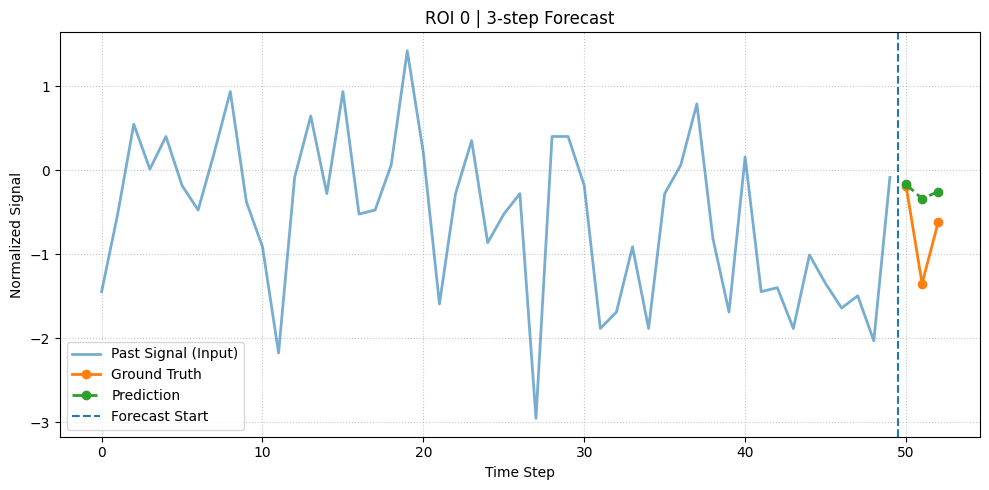


ROI 3


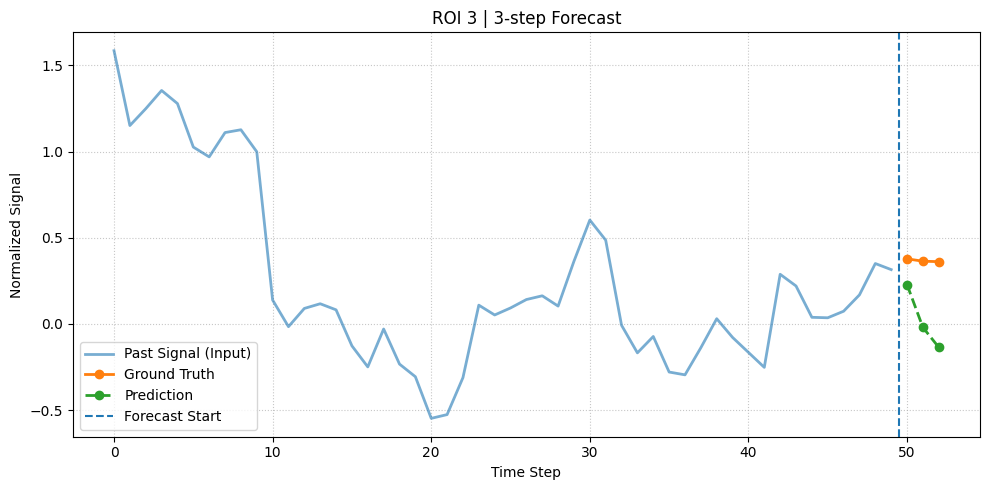


ROI 7


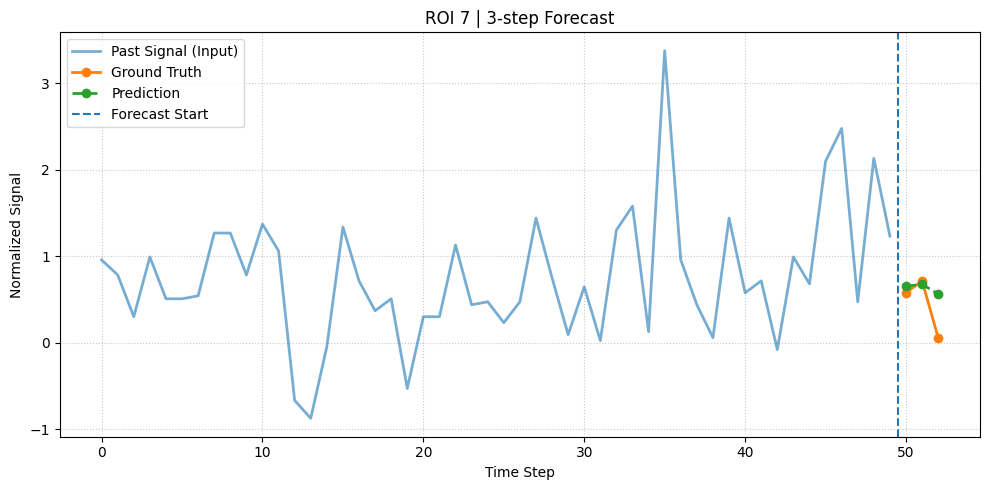

In [25]:
# =========================
# STEP 11: FINAL VISUALIZATION (INDIVIDUAL ROI PLOTS)
# (FIXED: align_mean=False — mean-shifting hides true prediction error)
# =========================

import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_single_roi_prediction(model, X_test, Y_test, device,
                                roi_idx=0, sample_idx=None,
                                align_mean=False):
    """
    Plot prediction vs ground truth for a single ROI.

    align_mean: if True, shifts predictions to match ground truth mean.
                WARNING: this artificially improves the visual appearance
                and should NOT be used when reporting results.
                Keep False for honest evaluation plots.
    """

    model.eval()

    if sample_idx is None:
        sample_idx = np.random.randint(len(X_test))

    with torch.no_grad():
        sample_x = torch.tensor(
            X_test[sample_idx:sample_idx + 1],
            dtype=torch.float32
        ).to(device)

        sample_y = Y_test[sample_idx]
        pred_y   = model(sample_x).cpu().numpy()[0]

        if align_mean:
            # Mean alignment: for exploration only, not for reporting
            print("WARNING: align_mean=True is enabled — plot is for exploration only.")
            pred_y = pred_y - pred_y.mean(axis=0) + sample_y.mean(axis=0)

    past_time   = np.arange(X_test.shape[1])
    future_time = np.arange(X_test.shape[1], X_test.shape[1] + Y_test.shape[1])

    plt.figure(figsize=(10, 5))

    plt.plot(past_time, X_test[sample_idx, :, roi_idx],
             label="Past Signal (Input)", linewidth=2, alpha=0.6)

    plt.plot(future_time, sample_y[:, roi_idx],
             "o-", label="Ground Truth", linewidth=2)

    plt.plot(future_time, pred_y[:, roi_idx],
             "o--", label="Prediction", linewidth=2)

    plt.axvline(x=X_test.shape[1] - 0.5, linestyle="--", label="Forecast Start")

    plt.title(f"ROI {roi_idx} | {Y_test.shape[1]}-step Forecast")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Signal")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.show()


def show_individual_roi_results(model, X_test, Y_test, device,
                                 roi_list=None, sample_idx=None):
    """
    Show separate prediction plots for each ROI in roi_list.
    Defaults to first 3 ROIs if roi_list is not provided.
    """

    if roi_list is None:
        n_roi = X_test.shape[2]
        roi_list = list(range(min(3, n_roi)))

    print("\nFINAL MODEL VISUALIZATION (INDIVIDUAL ROIs)")
    print("=" * 50)

    if sample_idx is None:
        sample_idx = np.random.randint(len(X_test))

    print(f"Using test sample index: {sample_idx}")

    for roi in roi_list:
        print(f"\nROI {roi}")
        plot_single_roi_prediction(
            model=model,
            X_test=X_test,
            Y_test=Y_test,
            device=device,
            roi_idx=roi,
            sample_idx=sample_idx,
            align_mean=False    # keep False for honest plots
        )


# =========================
# DIRECT OUTPUT
# =========================

show_individual_roi_results(
    model=model,
    X_test=X_test,
    Y_test=Y_test,
    device=device,
    roi_list=[0, 3, 7],
    sample_idx=None
)



Best sample idx: 207, Best ROI: 16, RMSE: 0.0121


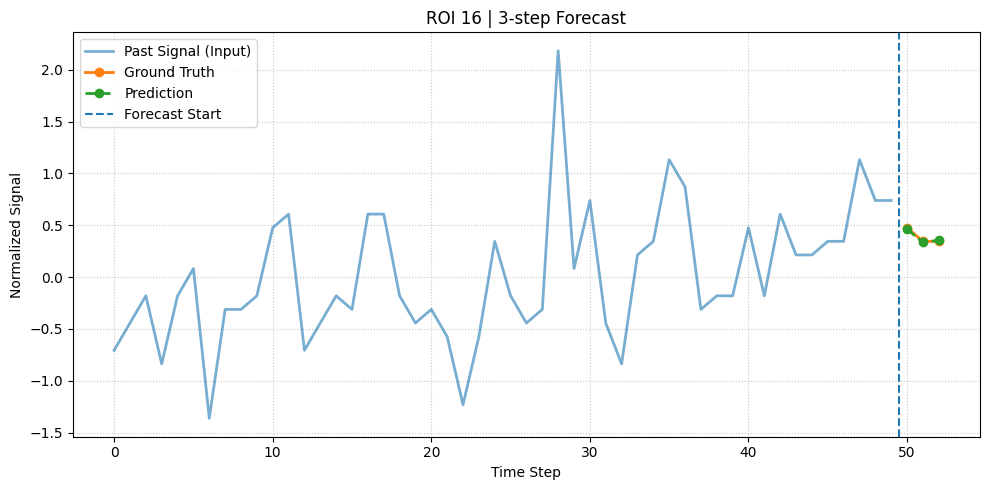

In [26]:
# Find best predicted sample AND best ROI
sample_idx = None
best_roi = None
best_err = float('inf')
model.eval()

with torch.no_grad():
    for i in range(min(500, len(X_test))):
        x = torch.tensor(X_test[i:i+1]).to(device)
        p = model(x).cpu().numpy()[0]
        for roi in range(X_test.shape[2]):
            err = np.sqrt(np.mean((Y_test[i, :, roi] - p[:, roi])**2))
            if err < best_err:
                best_err = err
                sample_idx = i
                best_roi = roi

print(f"Best sample idx: {sample_idx}, Best ROI: {best_roi}, RMSE: {best_err:.4f}")

plot_single_roi_prediction(
    model=model,
    X_test=X_test,
    Y_test=Y_test,
    device=device,
    roi_idx=best_roi,
    sample_idx=sample_idx,
    align_mean=False
)
plt.show()

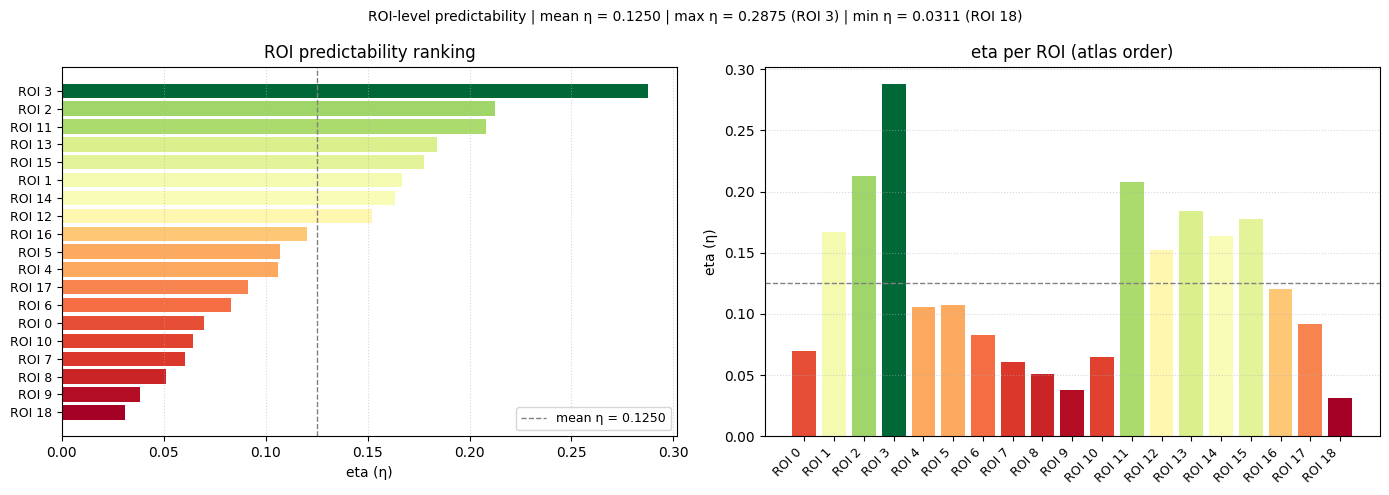


ROI-level eta summary:
ROI             eta    rank
----------------------------
ROI 3        0.2875       1
ROI 2        0.2124       2
ROI 11       0.2079       3
ROI 13       0.1841       4
ROI 15       0.1775       5
ROI 1        0.1670       6
ROI 14       0.1634       7
ROI 12       0.1520       8
ROI 16       0.1203       9
ROI 5        0.1072      10
ROI 4        0.1060      11
ROI 17       0.0914      12
ROI 6        0.0828      13
ROI 0        0.0696      14
ROI 10       0.0645      15
ROI 7        0.0606      16
ROI 8        0.0510      17
ROI 9        0.0382      18
ROI 18       0.0311      19

Most predictable  : ROI 3 (η=0.2875)
Least predictable : ROI 18 (η=0.0311)
Mean eta          : 0.1250
Std eta           : 0.0678


In [27]:
# =========================
# STEP 13: ROI-LEVEL ETA ANALYSIS
# Which brain regions are most predictable?
# =========================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

def compute_eta_per_roi(y_true, y_pred):
    """
    Compute information-theoretic eta separately for each ROI.

    η_roi = I(Y_roi; Ŷ_roi) / H(Y_roi)

    Returns:
        eta_per_roi : (n_roi,) array
    """
    if y_true.ndim == 3:
        y_true = y_true.reshape(-1, y_true.shape[-1])
        y_pred = y_pred.reshape(-1, y_pred.shape[-1])

    n_roi = y_true.shape[1]
    etas  = []

    for roi in range(n_roi):
        yt = y_true[:, roi]
        yp = y_pred[:, roi]

        if yt.std() < 1e-8 or yp.std() < 1e-8:
            etas.append(0.0)
            continue

        r = np.corrcoef(yt, yp)[0, 1]
        r = np.clip(r, -1 + 1e-7, 1 - 1e-7)

        mi = -0.5 * np.log(1 - r ** 2)
        hy =  0.5 * np.log(2 * np.pi * np.e * (yt.var() + 1e-12))
        etas.append(float(mi / (hy + 1e-12)))

    return np.array(etas)


def run_roi_eta_analysis(model, X_test, Y_test, device,
                          roi_labels=None):
    """
    Compute per-ROI eta and visualize as a ranked bar chart.

    roi_labels : list of ROI names (e.g. ['V1', 'V2', ...])
                 if None, uses ROI indices.
    """
    # Get predictions
    all_preds, all_targets = get_predictions(model,
        DataLoader(FMRIWindowDataset(X_test, Y_test),
                   batch_size=512, shuffle=False),
        device)

    eta_per_roi = compute_eta_per_roi(all_targets, all_preds)
    n_roi = len(eta_per_roi)

    if roi_labels is None:
        roi_labels = [f"ROI {i}" for i in range(n_roi)]

    # Sort by eta descending
    sorted_idx  = np.argsort(eta_per_roi)[::-1]
    sorted_eta  = eta_per_roi[sorted_idx]
    sorted_labels = [roi_labels[i] for i in sorted_idx]

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: ranked bar chart
    colors = cm.RdYlGn(
        (sorted_eta - sorted_eta.min()) /
        (sorted_eta.max() - sorted_eta.min() + 1e-8)
    )
    axes[0].barh(range(n_roi), sorted_eta[::-1],
                 color=colors[::-1])
    axes[0].set_yticks(range(n_roi))
    axes[0].set_yticklabels(sorted_labels[::-1], fontsize=9)
    axes[0].set_xlabel("eta (η)")
    axes[0].set_title("ROI predictability ranking")
    axes[0].axvline(x=eta_per_roi.mean(), color='gray',
                    linestyle='--', linewidth=1,
                    label=f"mean η = {eta_per_roi.mean():.4f}")
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', linestyle=':', alpha=0.5)

    # Right: raw bar chart in ROI order
    roi_colors = cm.RdYlGn(
        (eta_per_roi - eta_per_roi.min()) /
        (eta_per_roi.max() - eta_per_roi.min() + 1e-8)
    )
    axes[1].bar(range(n_roi), eta_per_roi, color=roi_colors)
    axes[1].set_xticks(range(n_roi))
    axes[1].set_xticklabels(roi_labels, rotation=45,
                             ha='right', fontsize=9)
    axes[1].set_ylabel("eta (η)")
    axes[1].set_title("eta per ROI (atlas order)")
    axes[1].axhline(y=eta_per_roi.mean(), color='gray',
                    linestyle='--', linewidth=1)
    axes[1].grid(axis='y', linestyle=':', alpha=0.5)

    plt.suptitle(
        f"ROI-level predictability | mean η = {eta_per_roi.mean():.4f} "
        f"| max η = {sorted_eta[0]:.4f} ({sorted_labels[0]}) "
        f"| min η = {sorted_eta[-1]:.4f} ({sorted_labels[-1]})",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\nROI-level eta summary:")
    print(f"{'ROI':<10} {'eta':>8}  {'rank':>6}")
    print("-" * 28)
    for rank, idx in enumerate(sorted_idx):
        print(f"{roi_labels[idx]:<10} {eta_per_roi[idx]:>8.4f}  {rank+1:>6}")

    print(f"\nMost predictable  : {sorted_labels[0]} (η={sorted_eta[0]:.4f})")
    print(f"Least predictable : {sorted_labels[-1]} (η={sorted_eta[-1]:.4f})")
    print(f"Mean eta          : {eta_per_roi.mean():.4f}")
    print(f"Std eta           : {eta_per_roi.std():.4f}")

    return eta_per_roi, sorted_idx


# =========================
# RUN
# =========================

# If you have ROI label names from the atlas, pass them here
# roi_labels = list(dataset[0]["roi_labels"])  # uncomment if available

eta_per_roi, sorted_idx = run_roi_eta_analysis(
    model=model,
    X_test=X_test,
    Y_test=Y_test,
    device=device,
    roi_labels=None    # or roi_labels=roi_labels
)

In [51]:
%%writefile model_library.py
import torch
import torch.nn as nn
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from torch.utils.data import Dataset, DataLoader

class FMRIWindowDataset(Dataset):
    """PyTorch dataset for fMRI windowed sequences."""

    def __init__(self, X, Y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = None
        if Y is not None:
          self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.Y is not None:
          return self.X[idx], self.Y[idx]
        return self.X[idx]


class AdvancedLSTM(nn.Module):
    """
    Multi-layer LSTM for multi-step fMRI BOLD forecasting.
    Takes a sequence of M past ROI vectors and predicts H future steps.
    """
    def __init__(self, input_size, hidden_size=512, num_layers=3, output_horizon=5, dropout=0.5):
        super().__init__()
        self.output_horizon = output_horizon
        self.input_size = input_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Maps the last hidden state to the full forecast window (H * ROI)
        self.fc = nn.Linear(hidden_size, output_horizon * input_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        _, (h_n, _) = self.lstm(x)

        # Use the hidden state from the last LSTM layer
        last_h = h_n[-1]
        out = self.fc(last_h)

        # Reshape to (Batch, Horizon, ROI)
        return out.view(-1, self.output_horizon, self.input_size)

class FmriPredictorAPI(BaseEstimator, RegressorMixin):
    """
    Scikit-Learn compatible API for the fMRI LSTM model.
    Encapsulates preprocessing (tensor conversion) and inference.
    """
    def __init__(self, model_obj=None, M=50, H=3, device='cpu'):
        self.model_obj = model_obj
        self.M = M
        self.H = H
        self.device = device

        if self.model_obj is not None:
            self.model_obj.to(self.device)
            self.model_obj.eval()

    def fit(self, X, y=None):
        """Exists for Scikit-Learn compatibility. No training performed here."""
        return self

    def predict(self, X, batch_size=512):
        """
        Performs inference on provided fMRI windows in batches.
        Input X: Numpy array of shape (N, M, ROI)
        Output: Numpy array of shape (N, H, ROI)
        """
        if self.model_obj is None:
            raise ValueError("Model object is not initialized.")

        self.model_obj.eval()

        inference_dataset = FMRIWindowDataset(X)
        inference_loader = DataLoader(
            inference_dataset,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True
        )

        all_predictions = []
        with torch.no_grad():
            for x_batch in inference_loader:
                x_batch = x_batch.to(self.device)
                predictions_batch = self.model_obj(x_batch)
                all_predictions.append(predictions_batch.cpu().numpy())

        return np.concatenate(all_predictions, axis=0)


Writing model_library.py


In [52]:
import joblib
import importlib
import model_library
import numpy as np

# Refresh the module (to get the updated FmriPredictorAPI class)
importlib.reload(model_library)
from model_library import FmriPredictorAPI

# 1. Wrap the model again as a Scikit-Learn API object and save it (previously deleted step)
fmri_sklearn_api = FmriPredictorAPI(
    model_obj=best_model,
    M=50,
    H=3,
    device=device
)

model_filename = "best_fmri_sklearn_api.joblib"
joblib.dump(fmri_sklearn_api, model_filename)
print(f"Model '{model_filename}' successfully saved.")

# 2. Load the saved model
loaded_fmri_sklearn_api = joblib.load(model_filename)
print(f"Model '{model_filename}' successfully loaded.")

Model 'best_fmri_sklearn_api.joblib' successfully saved.
Model 'best_fmri_sklearn_api.joblib' successfully loaded.


In [53]:
# Make predictions using the loaded model with batching
# X_test and Y_test are available from the previous execution
predictions = loaded_fmri_sklearn_api.predict(X_test, batch_size=512) # Specify a batch_size

print(f"Predictions shape: {predictions.shape}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


Predictions shape: (69600, 3, 19)


In [54]:
# Evaluate the predictions
# The compute_rmse and compute_eta functions are available from previous steps
rmse_loaded = compute_rmse(Y_test, predictions)
eta_loaded = compute_eta(Y_test, predictions)

print("\nEvaluation of loaded model:")
print(f"  RMSE: {rmse_loaded:.6f}")
print(f"  eta:  {eta_loaded:.4f}")



Evaluation of loaded model:
  RMSE: 0.767259
  eta:  0.1679
